In [24]:
import numpy as np
import pandas as pd 

# sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import momepy
import os
import glob

Creating Samples

C:\Users\mmosh\AppData\Local\Temp\ipykernel_19600\2754001315.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  Population['area'] = Population.geometry.area
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35043010601 of field tractsNM_9 of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35043010601 of field popul_bytr of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\mmosh\anaconda3\envs\CIE500\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 35001003600 of field tractsNM_9 of feature 0 not successfully written. Possibly due to too larger number with respect to 

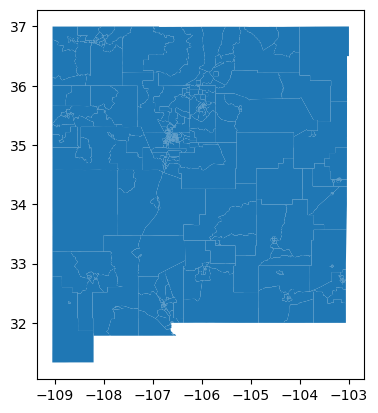

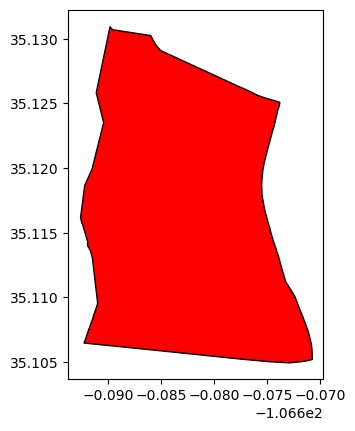

In [ ]:
Population = gpd.read_file("/Users/mmosh/Research-Project/Population/popul_bytracts2018.shp").explode(
                ignore_index=True, index_parts=False
           )[["geometry"]] #explod here means we break multilines in GIS into multiple simple lines.
    
Population['area'] = Population.geometry.area
Population.plot()
# Possibly don't need what is above.
    
tracts = gpd.read_file("/Users/mmosh/Research-Project/Population/popul_bytracts2018.shp")
    
Sample1 = tracts[tracts['popul_by_1'] == 4883]

Sample1.to_file('S1_Pop.shp')
#Sample1.plot(edgecolor='black', color='lightblue')

Sample2 = tracts[tracts['popul_by_1'] == 6839]

Sample2.to_file('S2_Pop.shp')
#Sample2.plot(edgecolor='black', color='lightgreen')

Sample3 = tracts[tracts['popul_by_1'] == 6809]

Sample3.to_file('S3_Pop.shp')
#Sample3.plot(edgecolor='black', color='lightgreen')

Sample4 = tracts[tracts['popul_by_1'] == 4303]

Sample4.to_file('S4_Pop.shp')
#Sample4.plot(edgecolor='black', color='lightgreen')

Sample5 = tracts[tracts['popul_by_1'] == 3573]

Sample5.to_file('S5_Pop.shp')
#Sample5.plot(edgecolor='black', color='lightgreen')

Sample6 = tracts[tracts['popul_by_1'] == 3510]

Sample6.to_file('S6_Pop.shp')
#Sample6.plot(edgecolor='black', color='lightgreen')

Sample7 = tracts[tracts['popul_by_1'] == 6541]

Sample7.to_file('S7_Pop.shp')
#Sample7.plot(edgecolor='black', color='lightgreen')

Sample8 = tracts[tracts['popul_by_1'] == 5195]

Sample8.to_file('S8_Pop.shp')
#Sample8.plot(edgecolor='black', color='lightgreen')

Sample9 = tracts[tracts['popul_by_1'] == 4814]

Sample9.to_file('S9_Pop.shp')
#Sample9.plot(edgecolor='black', color='lightgreen')

Sample10 = tracts[tracts['popul_by_1'] == 2699]

Sample10.to_file('S10_Pop.shp')
#Sample10.plot(edgecolor='black', color='lightgreen')

Sample11 = tracts[tracts['popul_by_1'] == 1968]

Sample11.to_file('S11_Pop.shp')
#Sample11.plot(edgecolor='black', color='lightgreen')

Sample12 = tracts[(tracts['popul_by_1'] == 3789) & (tracts['popul_by_2'] == 768)]

Sample12.to_file('S12_Pop.shp')
#Sample12.plot(edgecolor='black', color='lightgreen')

Sample13 = tracts[tracts['popul_by_1'] == 4391]

Sample13.to_file('S13_Pop.shp')
#Sample13.plot(edgecolor='black', color='red')

Sample14 = tracts[tracts['popul_by_1'] == 5270]

Sample14.to_file('S14_Pop.shp')
#Sample14.plot(edgecolor='black', color='red')

Sample15 = tracts[tracts['popul_by_1'] == 3068]

Sample15.to_file('S15_Pop.shp')
#Sample15.plot(edgecolor='black', color='red')

Sample16 = tracts[tracts['popul_by_1'] == 9017]

Sample16.to_file('S16_Pop.shp')
#Sample16.plot(edgecolor='black', color='red')

Sample17 = tracts[tracts['popul_by_1'] == 2790] 

Sample17.to_file('S17_Pop.shp')
#Sample17.plot(edgecolor='black', color='red')

Sample18 = tracts[tracts['popul_by_1'] == 5604]

Sample18.to_file('S18_Pop.shp')
#Sample18.plot(edgecolor='black', color='red')

Sample19 = tracts[tracts['popul_by_1'] == 3322]

Sample19.to_file('S19_Pop.shp')
#Sample19.plot(edgecolor='black', color='red')

Sample20 = tracts[tracts['popul_by_1'] == 4130]

Sample20.to_file('S20_Pop.shp')
#Sample20.plot(edgecolor='black', color='red')

files = glob.glob("C:\\Users\\mmosh\\Research-Project\\*.shp")
gdfs = [gpd.read_file(f) for f in files]

merged = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs
)

merged.to_file("SamplePop.shp")



Adding In All Datasets

In [ ]:
#Adding in Land Use
